# 🤖 Atelier 1 — Construire un premier agent SQL avec LangChain et Mistral

⏱️ **Durée : 35 à 45 minutes** · Niveau : débutant · Modèle : Mistral via LangChain

<img src="./assets/LC_L1_Top.png" width="480">

Dans ce notebook, nous construisons un **agent** capable de répondre à des questions sur une base de données musicale (**Chinook**) en écrivant lui-même ses requêtes SQL. Fil rouge : *poser une question en français, laisser l'agent interroger la base, obtenir une réponse expliquée.*

### 🎯 À la fin, vous saurez

- expliquer ce qu'est un **agent** et en quoi il diffère d'un simple appel au modèle ;
- transformer une fonction Python en **outil** (`@tool`) et la confier à un agent ;
- assembler modèle + outils + instructions avec [`create_agent`](https://docs.langchain.com/oss/python/langchain/agents) ;
- lire une **trace** d'agent : décision de Mistral, appel d'outil, exécution SQL, réponse finale ;
- distinguer ce que **décide Mistral** de ce qu'**exécute** réellement Python/SQLite.

> **Prérequis :** savoir exécuter des cellules Python. Aucune connaissance préalable des agents ni du SQL avancé n'est nécessaire.

## 🧠 Qu'est-ce qu'un agent ? (et pourquoi ce n'est pas « juste un chatbot »)

Un modèle de langage seul sait **rédiger**, pas **agir** sur une base de données. Un **agent** ajoute une boucle : le modèle peut demander l'exécution d'un **outil**, lire son résultat, puis continuer.

Imaginez un **analyste** et son **assistant SGBD** :

- **Mistral** joue l'analyste : il comprend la question et décide *quelle* requête écrire ;
- **LangChain** (`create_agent`) est le bureau qui organise l'aller-retour ;
- **Python + SQLite** sont l'assistant qui exécute *réellement* la requête ;
- l'analyste lit le résultat et rédige la réponse finale.

Sans outil, le modèle *inventerait* des chiffres. Avec l'outil `execute_sql`, chaque nombre provient réellement de la base.

## 📖 Mini-glossaire

| Terme | Définition simple |
|---|---|
| **Agent** | Boucle qui relie le modèle, des outils et des messages jusqu'à une réponse. |
| **Outil (tool)** | Fonction décrite pour que le modèle puisse décider de l'appeler. |
| **`create_agent`** | Fonction LangChain qui assemble modèle + outils + instructions. |
| **ReAct** | Motif « Reason + Act » : le modèle raisonne puis agit, en boucle. |
| **System prompt** | Instructions permanentes qui cadrent le comportement de l'agent. |
| **Contexte d'exécution** | Données partagées (ici la connexion à la base) transmises aux outils. |

## 🗺️ Le trajet d'une question

```text
Question en français
        ↓
Mistral décide : « il me faut des données » → prépare une requête SQL
        ↓
LangChain reçoit l'appel d'outil execute_sql
        ↓
Python exécute la requête sur SQLite (Chinook.db)
        ↓
Le résultat revient à Mistral (ToolMessage)
        ↓
Mistral rédige la réponse finale en français
```

⚠️ **Point clé :** Mistral *choisit* la requête, mais c'est **SQLite** qui l'exécute. Mistral décrit ce cycle en cinq étapes : [function calling](https://docs.mistral.ai/studio/conversations/function-calling).

## 🛠️ 0. Préparer Mistral

Nous utilisons l'intégration officielle [`ChatMistralAI`](https://docs.langchain.com/oss/python/integrations/chat/mistralai).

La cellule ci-dessous charge vos variables depuis `.env` avec `python-dotenv`, puis vérifie la présence de `MISTRAL_API_KEY` et `MISTRAL_SERVER_URL` **sans jamais afficher leur valeur** (`doublecheck_env` masque les secrets sous la forme `****xxxx`).

In [1]:
import os
from dotenv import load_dotenv, find_dotenv

# Charge les variables d'environnement depuis le fichier .env
load_dotenv(find_dotenv())

# Vérification de la présence de la clé API Mistral
if not os.getenv("MISTRAL_API_KEY"):
    raise ValueError("❌ MISTRAL_API_KEY non trouvée. Créez un fichier .env avec MISTRAL_API_KEY=votre_clé")
if not os.getenv("MISTRAL_SERVER_URL"):
    raise ValueError("❌ MISTRAL_SERVER_URL non trouvée. Créez un fichier .env avec MISTRAL_SERVER_URL=votre_url")

print("✅ Clé API Mistral chargée.")
print("✅ URL du serveur Mistral chargée.")

# Vérification des variables d'environnement et des packages requis
from util.env_utils import doublecheck_env, doublecheck_pkgs
doublecheck_env("../example.env")  # vérification des variables de l'environment
doublecheck_pkgs(pyproject_path="../pyproject.toml", verbose=True)   # vérification des packages requis

✅ Clé API Mistral chargée.
✅ URL du serveur Mistral chargée.
MISTRAL_API_KEY=****uLt0
MISTRAL_SERVER_URL=****l.ai
LANGSMITH_API_KEY=****3ba5
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ials


Python 3.13.13 satisfies requires-python: >=3.13
package                    | required | installed | status    | path                                                                            
-------------------------- | -------- | --------- | --------- | --------------------------------------------------------------------------------
langchain                  | >=1.0    | 1.3.18    | ✅ OK      | …eDrive - Accenture\Formation-Mistral-Public\J2_Hands On\.venv\Lib\site-packages
langchain-core             | >=1.0    | 1.6.1     | ✅ OK      | …eDrive - Accenture\Formation-Mistral-Public\J2_Hands On\.venv\Lib\site-packages
langchain-community        | >=0.3    | -         | ❌ Missing | -                                                                               
langchain-mistralai        | >=1.0    | 1.1.6     | ✅ OK      | …eDrive - Accenture\Formation-Mistral-Public\J2_Hands On\.venv\Lib\site-packages
langgraph                  | >=1.0    | 1.2.11    | ✅ OK      | …eDrive - Accentu

> 👀 **Résultat attendu :** deux ✅ (clé et URL chargées), puis un tableau de vérification des variables (masquées) et des paquets. Si une variable manque, la cellule s'arrête avec un message clair, **sans exposer de secret**.

### Instancier le modèle

`temperature=0` réduit la variabilité (utile pour du SQL). Le serveur de formation est dédié et **n'expose pas** `mistral-large-latest` : nous prenons `mistral-medium-latest`, le modèle de génération le plus capable disponible ici.

In [ ]:
from langchain_mistralai import ChatMistralAI

MODEL = "mistral-medium-latest"

# 📚 https://docs.langchain.com/oss/python/integrations/chat/mistralai
llm = ChatMistralAI(
    model=MODEL,
    temperature=0,
    endpoint=os.environ["MISTRAL_SERVER_URL"] + "/v1",
)

print(f"✅ Modèle {MODEL} initialisé.")

> 👀 **Résultat attendu :** `✅ Modèle mistral-medium-latest initialisé.` — aucune clé n'est affichée.

## 🗄️ 1. Connecter la base musicale Chinook

`Chinook` est une base SQLite de démonstration (artistes, albums, pistes, factures…). Nous l'ouvrons via un petit utilitaire local `SQLDatabase` (fichier `util/sql_db.py`), en **lecture seule** dans nos usages.

Original Link : https://github.com/lerocha/chinook-database

In [3]:
from util.sql_db import SQLDatabase

# Connexion à la base SQLite Chinook
db = SQLDatabase.from_uri("sqlite:///data/Chinook.db")
print("✅ Base de données Chinook connectée.")

✅ Base de données Chinook connectée.


> 👀 **Résultat attendu :** `✅ Base de données Chinook connectée.`

## 🧩 2. Définir le contexte d'exécution

Notre outil SQL a besoin de la connexion `db`. Plutôt qu'une variable globale, nous la transmettons proprement via un **contexte d'exécution** que LangGraph passera à chaque appel d'outil.

In [4]:
from dataclasses import dataclass
from util.sql_db import SQLDatabase

# Structure du contexte partagé entre l'agent et ses outils.
# L'agent transmettra cette structure à chaque appel d'outil.
@dataclass
class RuntimeContext:
    db: SQLDatabase

> 🔍 Aucune sortie : nous déclarons seulement une structure. `RuntimeContext` transportera la connexion `db` jusqu'à l'outil.

## 🛠️ 3. Créer l'outil `execute_sql`

Le décorateur [`@tool`](https://docs.langchain.com/oss/python/langchain/tools) transforme une fonction en outil : son **nom**, sa **docstring** et son **schéma** sont transmis au modèle pour qu'il sache *quand* et *comment* l'appeler.

> 🔮 **Pause prédiction :** pour « quelle table a le plus d'entrées ? », l'agent appellera-t-il `execute_sql` une fois, plusieurs fois, ou pas du tout ?

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

# @tool transforme cette fonction en outil que l'agent Mistral peut appeler.
# La docstring est transmise au modèle pour lui expliquer à quoi sert l'outil.
@tool
def execute_sql(query: str) -> str:
    """Exécute UNE requête SQL SQLite en lecture seule et renvoie le résultat.

    Utilise cet outil dès qu'une question nécessite des données de la base
    musicale. Fournis une seule requête SELECT valide.
    """
    # get_runtime() récupère le contexte partagé (la connexion BDD).
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        # En cas d'erreur SQL, on retourne le message d'erreur.
        # L'agent Mistral pourra corriger sa requête et réessayer.
        return f"Error: {e}"

> 🔍 **Qui fait quoi ?**
>
> | Acteur | Rôle |
> |---|---|
> | Python | définit la fonction et exécute vraiment le SQL sur SQLite. |
> | LangChain | fabrique la fiche de l'outil (nom, description, schéma) et gère la boucle. |
> | Mistral | décidera *s'il* appelle l'outil et *quelle* requête écrire. |

## 📋 4. Donner ses règles à l'agent (system prompt)

Le **system prompt** cadre le comportement : lecture seule, une seule requête `SELECT` à la fois, réponse en français, correction en cas d'erreur.

⚠️ C'est une *consigne*, pas une sécurité : un system prompt oriente le modèle mais ne remplace pas des droits SQL restreints côté base.

In [6]:
# Le system prompt définit les règles de comportement de l'agent.
# Il est transmis au modèle Mistral avant chaque conversation.
SYSTEM_PROMPT = """

Tu es un analyste SQL SQLite minutieux. Tu travailles sur une base de données musicale.

Règles :
- Réfléchis étape par étape.
- Quand tu as besoin de données, appelle l'outil `execute_sql` avec UNE SEULE requête SELECT.
- Lecture seule uniquement : aucun INSERT/UPDATE/DELETE/ALTER/DROP/CREATE.
- Limite à 5 lignes de résultats sauf si l'utilisateur demande explicitement davantage.
- Si l'outil retourne 'Error:', corrige le SQL et réessaie.
- Préfère les listes de colonnes explicites ; évite SELECT *.
- Réponds toujours en français.
"""

## 🤖 5. Assembler l'agent avec `create_agent`

[`create_agent`](https://docs.langchain.com/oss/python/langchain/agents) relie le modèle, les outils et les instructions dans une boucle **ReAct** prête à l'emploi.

In [7]:
from langchain.agents import create_agent

# create_agent assemble le modèle, les outils et les instructions.
# LangGraph gère automatiquement la logique de décision de l'agent (boucle ReAct).
agent = create_agent(
    model=llm,                     # Notre modèle ChatMistralAI
    tools=[execute_sql],           # Les outils disponibles
    system_prompt=SYSTEM_PROMPT,   # Les règles de comportement
    context_schema=RuntimeContext, # Le schéma du contexte partagé
)

print("✅ Agent créé avec succès.")

✅ Agent créé avec succès.


> 👀 **Résultat attendu :** `✅ Agent créé avec succès.`

## 🧭 6. Visualiser la boucle ReAct

LangGraph implémente la boucle **Reason + Act**. Le schéma montre un nœud `model` (Mistral décide) et un nœud `tools` (exécution), avec une boucle tant que le modèle demande des outils.

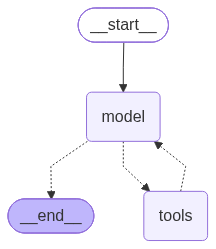

In [8]:
from IPython.display import Image, display

# Affiche le graphe interne de l'agent (boucle ReAct).
# draw_mermaid_png() interroge un service distant : on prévoit un repli hors-ligne.
graph = agent.get_graph(xray=True)
try:
    display(Image(graph.draw_mermaid_png()))
except Exception as erreur:  # pas de réseau / service indisponible
    print(f"ℹ️ Rendu image indisponible ({type(erreur).__name__}). Voici le schéma en texte :")
    print(graph.draw_mermaid())

> 👀 **Résultat attendu :** un schéma (image *ou* texte de repli) reliant `model` et `tools` par une boucle.

## ▶️ 7. Poser une première question

> 🔮 **Pause prédiction :** dans la trace, repérez l'ordre attendu : question → décision (appel `execute_sql`) → résultat SQL → réponse finale.

In [9]:
question = "Quelle table possède le plus grand nombre d'entrées ?"

# agent.stream() exécute l'agent et diffuse les étapes une par une.
# À chaque étape, on affiche le dernier message (question, appel outil, réponse).
for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Quelle table possède le plus grand nombre d'entrées ?


================================== Ai Message ==================================

Pour déterminer quelle table possède le plus grand nombre d'entrées, je vais suivre ces étapes :

1. **Lister toutes les tables** de la base de données.
2. **Compter le nombre d'entrées** pour chaque table.
3. **Identifier la table avec le plus grand nombre d'entrées**.

Je commence par lister toutes les tables disponibles dans la base de données.
Tool Calls:
  execute_sql (2ArOADksF)
 Call ID: 2ArOADksF
  Args:
    query: SELECT name FROM sqlite_master WHERE type = 'table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]


================================== Ai Message ==================================
Tool Calls:
  execute_sql (uktWrRPe5)
 Call ID: uktWrRPe5
  Args:
    query: SELECT name, (SELECT COUNT(*) FROM sqlite_master WHERE name = t.name AND type = 'table') AS row_count FROM sqlite_master t WHERE type = 'table' ORDER BY row_count DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('Album', 1)]


================================== Ai Message ==================================

Je vais compter le nombre d'entrées pour chaque table pour identifier celle qui en possède le plus. Je vais interroger chaque table individuellement.
Tool Calls:
  execute_sql (nMEkYHzbP)
 Call ID: nMEkYHzbP
  Args:
    query: SELECT COUNT(*) AS count FROM Album;
================================= Tool Message =================================
Name: execute_sql

[(347,)]


================================== Ai Message ==================================
Tool Calls:
  execute_sql (niUGTK2EZ)
 Call ID: niUGTK2EZ
  Args:
    query: SELECT COUNT(*) AS count FROM Artist;
================================= Tool Message =================================
Name: execute_sql

[(275,)]


...

================================== Ai Message ==================================
Tool Calls:
  execute_sql (ZPIRS1tbL)
 Call ID: ZPIRS1tbL
  Args:
    query: SELECT COUNT(*) AS count FROM Employee;
================================= Tool Message =================================
Name: execute_sql

[(8,)]


================================== Ai Message ==================================
Tool Calls:
  execute_sql (mmb3ljvmA)
 Call ID: mmb3ljvmA
  Args:
    query: SELECT COUNT(*) AS count FROM Genre;
================================= Tool Message =================================
Name: execute_sql

[(25,)]


================================== Ai Message ==================================
Tool Calls:
  execute_sql (xLdsK8nV5)
 Call ID: xLdsK8nV5
  Args:
    query: SELECT COUNT(*) AS count FROM Invoice;
================================= Tool Message =================================
Name: execute_sql

[(412,)]


================================== Ai Message ==================================
Tool Calls:
  execute_sql (E2AeoccwJ)
 Call ID: E2AeoccwJ
  Args:
    query: SELECT COUNT(*) AS count FROM InvoiceLine;
================================= Tool Message =================================
Name: execute_sql

[(2240,)]


================================== Ai Message ==================================

La table **InvoiceLine** possède le plus grand nombre d'entrées avec **2 240** lignes.


> 🔍 **Lecture de la trace :** vous devriez voir un `HumanMessage`, un `AIMessage` contenant un appel `execute_sql` (la requête générée par Mistral), un `ToolMessage` (le résultat renvoyé par SQLite), puis l'`AIMessage` final. La formulation peut varier ; **l'appel d'outil et le `ToolMessage` sont les preuves stables** que la réponse vient bien de la base.

## ▶️ 8. Une question qui demande un calcul

Ici l'agent doit agréger (durée moyenne des pistes par genre). Observez qu'il peut enchaîner exploration puis requête finale avant de conclure.

In [10]:
question = "Quel genre musical possède en moyenne les pistes les plus longues ?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Quel genre musical possède en moyenne les pistes les plus longues ?


================================== Ai Message ==================================

Pour répondre à cette question, je vais suivre ces étapes :

1. **Identifier les tables pertinentes** : Je dois trouver les tables qui contiennent les informations sur les **genres musicaux** et les **pistes** (ou morceaux), ainsi que leur durée.
2. **Comprendre les relations** : Vérifier comment les genres sont liés aux pistes (par exemple, via une table intermédiaire ou une clé étrangère).
3. **Calculer la durée moyenne** : Pour chaque genre, calculer la durée moyenne de ses pistes.
4. **Trouver le genre avec la durée moyenne la plus élevée**.

Je vais commencer par explorer les tables disponibles pour comprendre la structure de la base de données. Je vais lister les tables.
Tool Calls:
  execute_sql (heMsENs0W)
 Call ID: heMsENs0W
  Args:
    query: SELECT name FROM sqlite_master WHERE type = 'table';
================================= Tool Message =================================
Name: execute_sql

[(

================================== Ai Message ==================================

Pour déterminer quel genre musical possède en moyenne les pistes les plus longues, je vais suivre ces étapes :

1. Identifier les colonnes pertinentes dans les tables **Genre** et **Track** pour relier les genres aux pistes et à leur durée.
2. Calculer la durée moyenne des pistes pour chaque genre.
3. Trier les résultats par durée moyenne décroissante et sélectionner le genre avec la valeur la plus élevée.

Je vais d'abord examiner la structure des tables **Genre** et **Track**.
Tool Calls:
  execute_sql (YD7n48eEM)
 Call ID: YD7n48eEM
  Args:
    query: SELECT name, sql FROM sqlite_master WHERE name IN ('Genre', 'Track');
================================= Tool Message =================================
Name: execute_sql

[('Genre', 'CREATE TABLE [Genre]\n(\n    [GenreId] INTEGER  NOT NULL,\n    [Name] NVARCHAR(120),\n    CONSTRAINT [PK_Genre] PRIMARY KEY  ([GenreId])\n)'), ('Track', 'CREATE TABLE [Track]\

================================== Ai Message ==================================
Tool Calls:
  execute_sql (0hJUkUmRo)
 Call ID: 0hJUkUmRo
  Args:
    query: SELECT Genre.Name, AVG(Track.Milliseconds) AS avg_duration_ms FROM Genre JOIN Track ON Genre.GenreId = Track.GenreId GROUP BY Genre.GenreId ORDER BY avg_duration_ms DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('Sci Fi & Fantasy', 2911783.0384615385)]


================================== Ai Message ==================================

Le genre musical qui possède en moyenne les pistes les plus longues est **Sci Fi & Fantasy**, avec une durée moyenne d'environ **2 911 783 millisecondes** (soit environ 48,5 minutes par piste).


> 👀 **Résultat attendu :** au moins un appel `execute_sql` (avec `AVG`/`GROUP BY`), un `ToolMessage`, puis une réponse en français nommant le genre gagnant.

## ▶️ 9. Afficher une réponse en Markdown

`stream_mode="values"` renvoie l'état complet à chaque étape ; on conserve le dernier message et on le rend joliment en **Markdown**.

In [11]:
from IPython.display import Markdown, display

question = "Liste tous les artistes dont le nom commence par 'A'."

dernier_message = None
for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    dernier_message_stream = step["messages"][-1].pretty_print()
    dernier_message = step["messages"][-1]

# Rendu Markdown de la réponse finale
display(Markdown(dernier_message.content))

================================ Human Message =================================

Liste tous les artistes dont le nom commence par 'A'.


================================== Ai Message ==================================
Tool Calls:
  execute_sql (Gj1TYb4Ap)
 Call ID: Gj1TYb4Ap
  Args:
    query: SELECT name FROM artists WHERE name LIKE 'A%' ORDER BY name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: artists
[SQL: SELECT name FROM artists WHERE name LIKE 'A%' ORDER BY name LIMIT 5;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


================================== Ai Message ==================================
Tool Calls:
  execute_sql (538hGpvVq)
 Call ID: 538hGpvVq
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',)]


================================== Ai Message ==================================
Tool Calls:
  execute_sql (j01kcKNi2)
 Call ID: j01kcKNi2
  Args:
    query: SELECT Name FROM Artist WHERE Name LIKE 'A%' ORDER BY Name LIMIT 5;
================================= Tool Message =================================
Name: execute_sql

[('A Cor Do Som',), ('AC/DC',), ('Aaron Copland & London Symphony Orchestra',), ('Aaron Goldberg',), ('Academy of St. Martin in the Fields & Sir Neville Marriner',)]


================================== Ai Message ==================================

Voici les 5 premiers artistes dont le nom commence par **"A"** dans la base de données :

1. A Cor Do Som
2. AC/DC
3. Aaron Copland & London Symphony Orchestra
4. Aaron Goldberg
5. Academy of St. Martin in the Fields & Sir Neville Marriner

Si tu veux voir plus de résultats, fais-le-moi savoir !


Voici les 5 premiers artistes dont le nom commence par **"A"** dans la base de données :

1. A Cor Do Som
2. AC/DC
3. Aaron Copland & London Symphony Orchestra
4. Aaron Goldberg
5. Academy of St. Martin in the Fields & Sir Neville Marriner

Si tu veux voir plus de résultats, fais-le-moi savoir !

> 👀 **Résultat attendu :** la liste des artistes commençant par « A », affichée en Markdown sous la trace.

## 🧪 Micro-exercice — Votre propre question

Posez **votre** question à l'agent (par exemple : « Quels sont les 3 pays qui ont le plus dépensé ? »).

### ✅ Critères de réussite
- la trace contient au moins un appel `execute_sql` avec une requête `SELECT` ;
- un `ToolMessage` renvoie des lignes de la base ;
- la réponse finale est en français et cohérente avec le résultat SQL.

💡 Le squelette ci-dessous est **commenté** pour que « Run All » fonctionne avant votre essai.

In [12]:
# 👉 À vous : décommentez puis remplacez la question par la vôtre.
# question = "TODO : votre question sur la base musicale"
#
# for step in agent.stream(
#     {"messages": question},
#     context=RuntimeContext(db=db),
#     stream_mode="values",
# ):
#     step["messages"][-1].pretty_print()

<details>
<summary>✅ Voir une correction possible</summary>

```python
question = "Quels sont les 3 pays dont le total facturé est le plus élevé ?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()
```

L'agent devrait interroger la table `Invoice` (somme de `Total` groupée par `BillingCountry`), puis présenter les trois premiers pays. La formulation varie ; l'appel `execute_sql` et le `ToolMessage` doivent apparaître.
</details>

## 🎛️ Bonus — Voir cet agent dans LangGraph Studio

Le même type d'agent SQL peut s'explorer dans **LangGraph Studio**, un débogueur
visuel qui affiche le graphe et chaque étape de décision, en local dans votre
navigateur.

Depuis le dossier `J2_Hands On` (dans un terminal, **pas** dans le notebook) :

```powershell
# 1) Fournir vos variables au studio (créez studio/.env avec vos clés)
Copy-Item .env studio\.env      # si vous utilisez un fichier .env

# 2) Lancer le serveur de dev (langgraph-cli est déjà installé)
cd studio
uv run --project .. langgraph dev
```

Une page s'ouvre : choisissez le graphe `agent2`, posez une question sur la base
musicale, et observez l'agent **décider** puis **interroger** la base — exactement ce
que nous venons de faire, mais en visuel.

📚 [LangGraph Studio](https://docs.langchain.com/oss/python/langchain/studio)

## 🧭 Ce qu'il faut retenir

- ✅ un **agent** = modèle + outils + boucle : il **agit**, il ne fait pas que répondre ;
- ✅ `@tool` transforme une fonction Python en capacité que Mistral peut décider d'appeler ;
- ✅ `create_agent` assemble le tout en une boucle **ReAct** ;
- ✅ dans la trace, l'**appel d'outil** et le **`ToolMessage`** prouvent que les données viennent de la base ;
- ✅ Mistral *décide*, Python/SQLite *exécutent*.

### ⚠️ Du notebook à la production
| Démonstration | En production |
|---|---|
| system prompt « lecture seule » | droits SQL réellement restreints côté base |
| `Error:` renvoyé au modèle | garde-fous, quotas et journalisation |
| une question à la fois | mémoire, tests et supervision |

### 🧭 Transition vers l'Atelier 2
Nous avons vu l'agent **agir**. Dans **l'Atelier 2 — Messages**, nous ouvrons le capot : comment LangChain représente une conversation en **messages** (`HumanMessage`, `AIMessage`, `ToolMessage`) et ce qu'ils contiennent.

## 📚 Documentation officielle

- [LangChain · Agents (`create_agent`)](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain · Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [LangChain · Intégration ChatMistralAI](https://docs.langchain.com/oss/python/integrations/chat/mistralai)
- [Mistral · Function calling (les 5 étapes)](https://docs.mistral.ai/studio/conversations/function-calling)